# DEGs between scRNA-seq cell types

This notebook analyzes single-cell RNA-seq data from iPSCs, definitive endoderm (DE), and primitive gut tube (PGT) cells.

## Input

- Scanpy object generated in notebook 6 (scRNA.h5ad)

## Output 

- Table S3: DEGs between cell types
- Figure 2e: Heatmap with top DEGs
- Figure 2f: Scatter plots with correlation in expression between cell types
- Figure S5d: Lineplot showing average expression of DEG categories

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation
from statsmodels.stats.multitest import multipletests

# scRNA-seq analysis
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))
import scanpy as sc

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10))
sns.set_style("ticks")

# Versions
sc.logging.print_versions()

-----
anndata     0.11.4
scanpy      1.10.3
-----
PIL                         10.4.0
anyio                       NA
argcomplete                 NA
arrow                       1.4.0
asttokens                   NA
attr                        25.4.0
attrs                       25.4.0
babel                       2.16.0
brotli                      1.2.0
certifi                     2026.02.25
cffi                        2.0.0
charset_normalizer          3.3.2
colorama                    0.4.6
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.17
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.1
fastjsonschema              NA
fqdn                        NA
h5py                        3.12.1
idna                        3.11
ipykernel                   6.26.0
ipywidgets                  8.1.

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = output_dir

# Settings
labels = ["iPSC", "DE", "PGT"]                                     # custom labels
samples = ["GSM9145591_iPSCs", "GSM9145592_DE", "GSM9145593_PGT"]  # base names of count files
colors = ["#264653", "#E9C46A", "#E76F51"]                         # colors to use
palette = dict(zip(labels, colors))                                # palette for plots

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype', 'Celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'Harmo

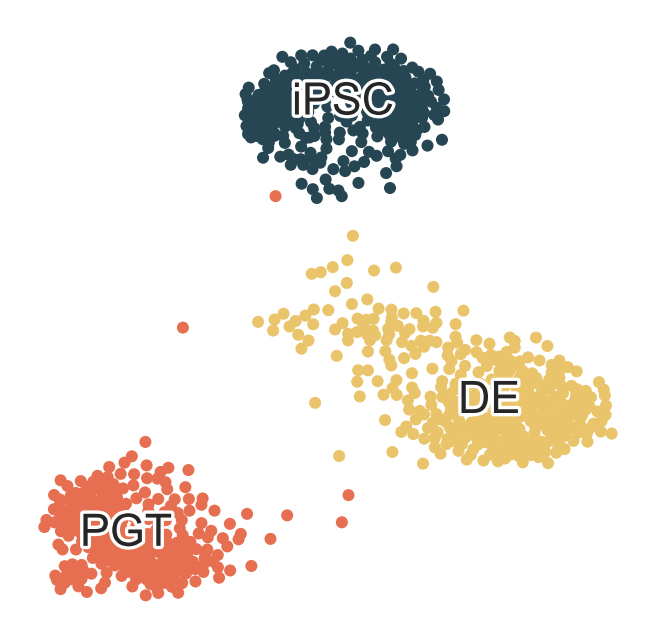

In [3]:
# Load scRNA-seq dataset
adata = sc.read_h5ad(f"{output_dir}/scRNA.h5ad")
print(adata)

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="",
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3, show=True)

## Figure 2e: Heatmap with top DEGs

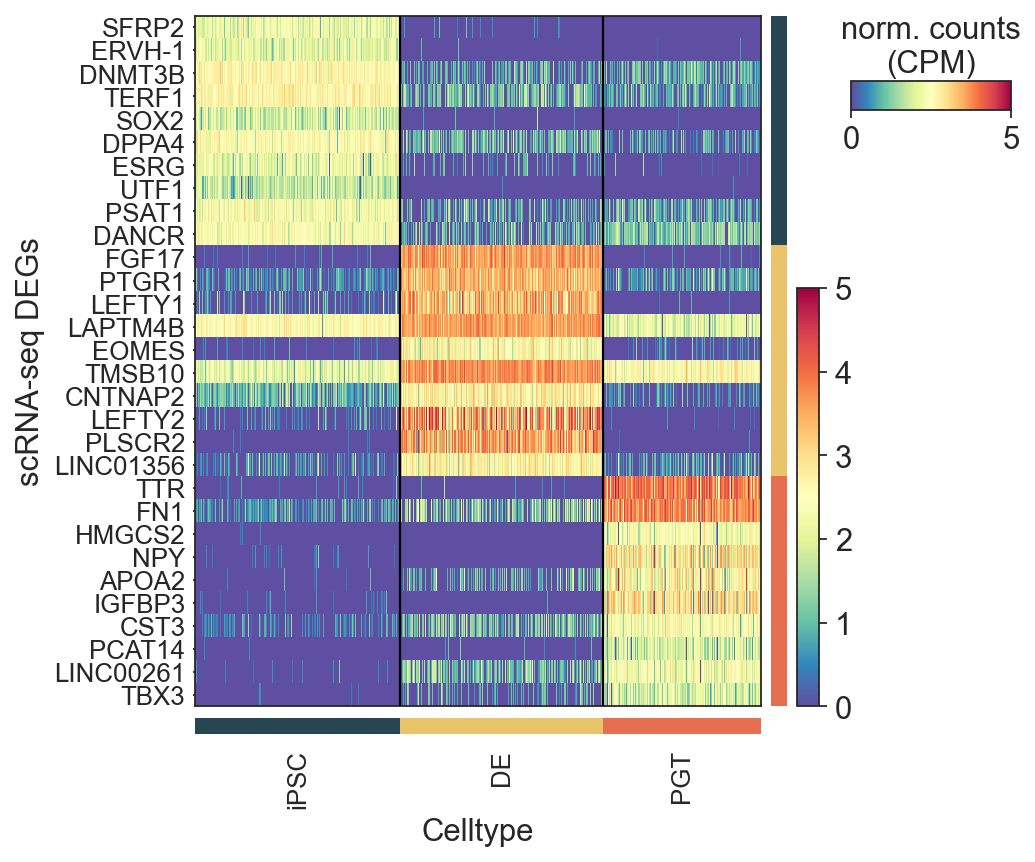

In [4]:
# DEGs between cell types
sc.tl.rank_genes_groups(adata, groupby="Celltype", method="wilcoxon", key_added="Celltype")

# Heatmap with DEGs
g = sc.pl.rank_genes_groups_heatmap(adata, n_genes=10, key="Celltype", groupby="Celltype", show_gene_labels=True, cmap="Spectral_r", 
                                swap_axes=True, figsize=(5,6), dendrogram=False, show=False, vmin=0, vmax=5)
g["heatmap_ax"].set_ylabel("scRNA-seq DEGs")

cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), cmap="Spectral_r"), 
                    cax=plt.gcf().add_axes([1, 0.8, 0.2, 0.03]), orientation="horizontal")
cbar.set_label("norm. counts\n(CPM)")
cbar.set_ticks([0, 5])
cbar.ax.xaxis.set_label_position("top")

plt.savefig(f"{output_dir}/Figure2e.svg", format="svg", bbox_inches="tight")
plt.show()

In [5]:
# Table with DEGs
degs = sc.get.rank_genes_groups_df(adata, group=None, key="Celltype")
display(degs)

degs.to_csv(f"{output_dir}/SupplementalTable3.txt", sep="\t", index=False)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,iPSC,SFRP2,26.595261,8.284877,7.701220e-156,1.507187e-151
1,iPSC,ERVH-1,26.592836,8.634070,8.215121e-156,1.507187e-151
2,iPSC,DNMT3B,26.526022,3.846034,4.857166e-155,5.940800e-151
3,iPSC,TERF1,26.514334,3.496398,6.624909e-155,6.077194e-151
4,iPSC,SOX2,26.330429,8.206783,8.600517e-153,5.259646e-149
...,...,...,...,...,...,...
110074,PGT,IFITM3,-23.218590,-2.081784,2.955301e-119,5.421942e-116
110075,PGT,L1TD1,-24.014507,-4.386978,1.961763e-127,5.998580e-124
110076,PGT,MIR302CHG,-24.300924,-4.271605,1.916680e-130,1.004697e-126
110077,PGT,TMSB4X,-24.631298,-3.102809,5.838931e-134,5.356197e-130


## Figure 2f: Scatter plots with correlation in expression between cell types

In [6]:
# Mean expression per cell type
avg_counts = pd.DataFrame(adata.layers["CPM"].toarray(), index=adata.obs.index, columns=adata.var_names)
avg_counts["Celltype"] = adata.obs["Celltype"].values
avg_counts = avg_counts.groupby("Celltype").mean().T
display(avg_counts)

Celltype,iPSC,DE,PGT
MIR1302-2HG,0.000000,0.000000,0.000000
FAM138A,0.000000,0.000000,0.000000
OR4F5,0.000000,0.000000,0.000000
AL627309.1,0.205345,0.833383,0.771237
AL627309.3,0.000000,0.000000,0.000000
...,...,...,...
ERCC-00164,0.418747,0.966150,0.000000
ERCC-00165,5.759097,8.477218,10.424499
ERCC-00168,0.126652,0.641207,0.451892
ERCC-00170,2.636265,5.623537,4.560140


In [7]:
# DEGs per cell type
degs = pd.read_csv(f"{output_dir}/SupplementalTable3.txt", sep="\t")

ipsc_degs = degs[(degs["group"] == "iPSC") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]
de_degs = degs[(degs["group"] == "DE") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]
pgt_degs = degs[(degs["group"] == "PGT") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]

print(f"Total number of genes: {len(degs)}")
print(f"DEGs in iPSCs: {len(ipsc_degs)}")
print(f"DEGs in DE: {len(de_degs)}")
print(f"DEGS in PGT: {len(pgt_degs)}")

Total number of genes: 110079
DEGs in iPSCs: 1774
DEGs in DE: 813
DEGS in PGT: 1499


In [8]:
# Annotate average expression with DEG status
avg_counts["DEGs"] = np.where(avg_counts.index.isin(ipsc_degs), "iPSC",
                     np.where(avg_counts.index.isin(de_degs), "DE",
                     np.where(avg_counts.index.isin(pgt_degs), "PGT", "n.s.")))
avg_counts["DEGs"] = pd.Categorical(avg_counts["DEGs"], categories=labels + ["n.s."], ordered=True)

# Add pseudocount to CPMs, and log-transform
avg_counts[labels] = np.log2(avg_counts[labels] + 0.1)
display(avg_counts)

Celltype,iPSC,DE,PGT,DEGs
MIR1302-2HG,-3.321928,-3.321928,-3.321928,n.s.
FAM138A,-3.321928,-3.321928,-3.321928,n.s.
OR4F5,-3.321928,-3.321928,-3.321928,n.s.
AL627309.1,-1.711489,-0.099458,-0.198864,n.s.
AL627309.3,-3.321928,-3.321928,-3.321928,n.s.
...,...,...,...,...
ERCC-00164,-0.946896,0.092410,-3.321928,n.s.
ERCC-00165,2.550678,3.100510,3.395680,n.s.
ERCC-00168,-2.141448,-0.432053,-0.857543,n.s.
ERCC-00170,1.452208,2.516907,2.220373,n.s.


In [9]:
correlations = avg_counts[["iPSC", "DE", "PGT"]].corr(method="pearson")
display(correlations)

Celltype,iPSC,DE,PGT
Celltype,,,
iPSC,1.000000,0.925973,0.928519
DE,0.925973,1.000000,0.927061
PGT,0.928519,0.927061,1.000000


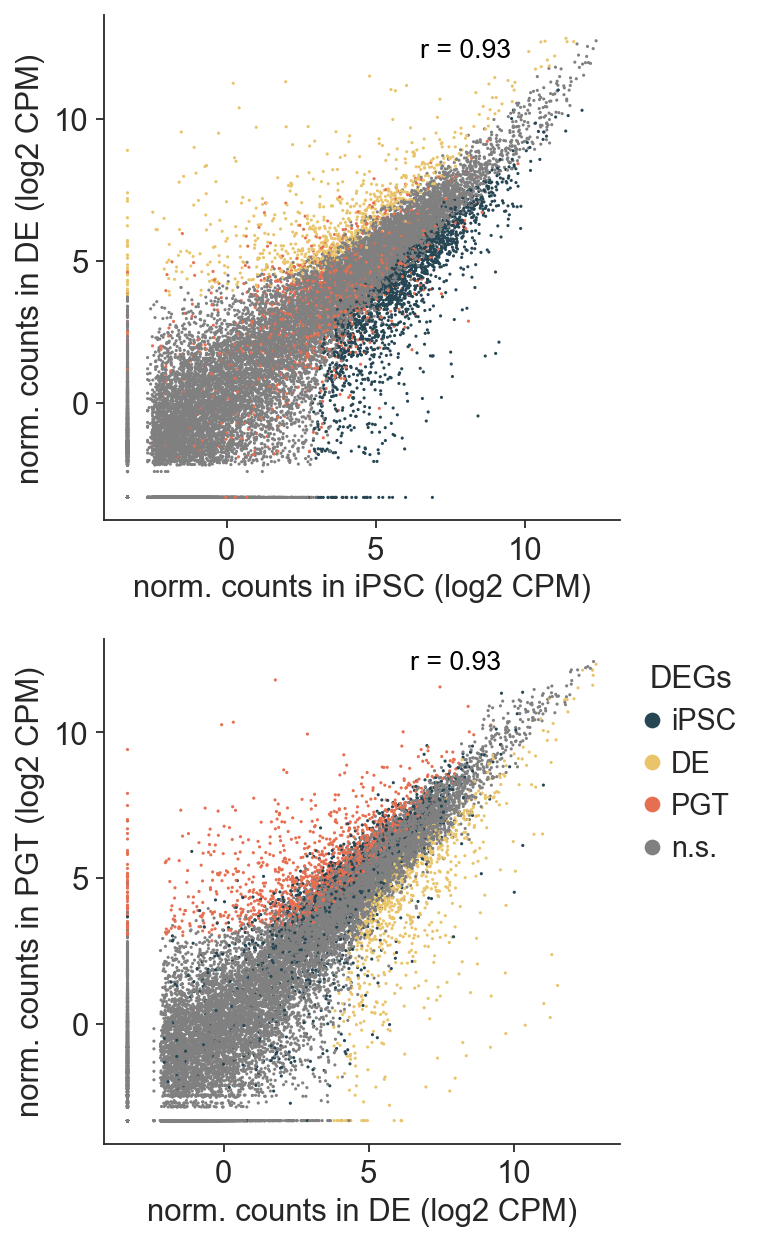

In [10]:
palette_ns = {**palette, "n.s.": "gray"}

scatter_pairs = [("iPSC", "DE"), ("DE", "PGT")]

fig, axs = plt.subplots(2, 1, figsize=(5, 8))

for ax, (x, y) in zip(axs, scatter_pairs):
    sns.scatterplot(ax=ax, x=avg_counts[x], y=avg_counts[y], hue=avg_counts["DEGs"], 
                    linewidth=0, s=2, palette=palette_ns)
    ax.set(xlabel=f"norm. counts in {x} (log2 CPM)", ylabel=f"norm. counts in {y} (log2 CPM)", xticks=[0, 5, 10], yticks=[0, 5, 10])

    corr, _ = scipy.stats.pearsonr(avg_counts[x], avg_counts[y])
    ax.annotate(f"r = {corr:.2f}", xy=(8, 12), color="black", fontsize=12, ha="center", va="bottom")
    
axs[0].get_legend().remove()
axs[1].legend(markerscale=5, frameon=False, loc="upper left", bbox_to_anchor=(1, 1), title="DEGs") 

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure2f.svg", format="svg")
plt.show()

## Figure S5d: Lineplot showing average expression of DEG categories

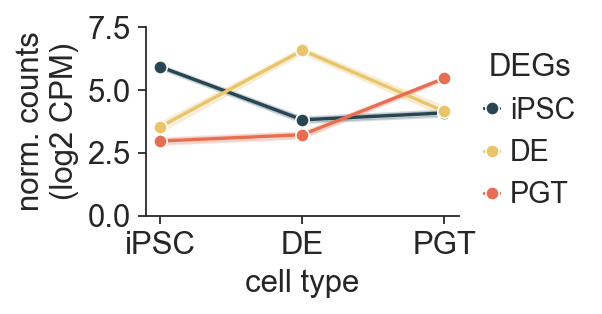

In [11]:
avg_melted = avg_counts.melt(id_vars="DEGs", value_vars=["iPSC", "DE", "PGT"], var_name="cell type", value_name="mean expression")
avg_melted = avg_melted[avg_melted["DEGs"] != "n.s."]
avg_melted["DEGs"] = pd.Categorical(avg_melted["DEGs"], categories=labels, ordered=True)

plt.figure(figsize=(4, 2.2))
sns.lineplot(data=avg_melted, x="cell type", y="mean expression", hue="DEGs", marker="o", palette=palette,
             estimator="mean", errorbar=("ci", 95))
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1), title="DEGs") 
plt.ylabel("norm. counts\n(log2 CPM)")
plt.ylim(0, 7.5)
plt.yticks([0, 2.5, 5, 7.5])

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure5d.svg", format="svg")
plt.show()